Clona Projeto direto do github para facilitar

In [1]:
!git clone https://github.com/carbon-footprint-analysis/carbon-footprint-analysis.git

Cloning into 'carbon-footprint-analysis'...
remote: Enumerating objects: 129, done.
remote: Counting objects: 100% (129/129), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 129 (delta 34), reused 114 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (129/129), 2.27 MiB | 7.24 MiB/s, done.
Resolving deltas: 100% (34/34), done.


importa dados oficiais da empresa de pesquisa energetica e faz EDA + ETL para criar o dataset sintetico ainda !

Abaixo e o data set de consumo por categoria e estado o consumo esta em MW mas abaixo sera convertido para kwh

In [2]:
import pandas as pd

epe = pd.read_csv('/content/carbon-footprint-analysis/data/raw/epe_industrial_consumption_by_state.csv',
                    encoding='latin-1',
                    sep=';',
                    decimal=',')

In [3]:
epe.head()

,Coluna1,DataExcel,SetorIndustrial,UF,Regiao,Consumo,DataVersao
0,20251201,01/12/2025,05 - EXTRAÇÃO DE CARVÃO MINERAL,AM,Norte,15.000,23/02/2026
1,20251201,01/12/2025,05 - EXTRAÇÃO DE CARVÃO MINERAL,DF,Centro-Oeste,1.077,23/02/2026
2,20251201,01/12/2025,05 - EXTRAÇÃO DE CARVÃO MINERAL,ES,Sudeste,23.000,23/02/2026
3,20251201,01/12/2025,05 - EXTRAÇÃO DE CARVÃO MINERAL,MA,Nordeste,39.586,23/02/2026
4,20251201,01/12/2025,05 - EXTRAÇÃO DE CARVÃO MINERAL,MG,Sudeste,20994.000,23/02/2026


In [4]:
epe['DataExcel'] = pd.to_datetime(epe['DataExcel'], dayfirst=True)

In [5]:
epe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135676 entries, 0 to 135675
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Coluna1          135676 non-null  int64         
 1   DataExcel        135676 non-null  datetime64[ns]
 2   SetorIndustrial  135676 non-null  object        
 3   UF               135676 non-null  object        
 4   Regiao           135676 non-null  object        
 5   Consumo          135676 non-null  float64       
 6   DataVersao       135676 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 7.2+ MB


In [6]:
epe['SetorIndustrial'].unique()

array(['05 - EXTRAÇÃO DE CARVÃO MINERAL',
       '06 - EXTRAÇÃO DE PETRÓLEO E GÁS NATURAL',
       '07 - EXTRAÇÃO DE MINERAIS METÁLICOS',
       '08 - EXTRAÇÃO DE MINERAIS NÃO-METÁLICOS',
       '09 - ATIVIDADES DE APOIO À EXTRAÇÃO DE MINERAIS',
       '10 - FABRICAÇÃO DE PRODUTOS ALIMENTÍCIOS',
       '11 - FABRICAÇÃO DE BEBIDAS',
       '12 - FABRICAÇÃO DE PRODUTOS DO FUMO',
       '13 - FABRICAÇÃO DE PRODUTOS TÊXTEIS',
       '14 - CONFECÇÃO DE ARTIGOS DO VESTUÁRIO E ACESSÓRIOS',
       '15 - PREPARAÇÃO DE COUROS E FABRICAÇÃO DE ARTEFATOS DE COURO, ARTIGOS PARA VIAGEM E CALÇADOS',
       '16 - FABRICAÇÃO DE PRODUTOS DE MADEIRA',
       '17 - FABRICAÇÃO DE CELULOSE, PAPEL E PRODUTOS DE PAPEL',
       '18 - IMPRESSÃO E REPRODUÇÃO DE GRAVAÇÕES',
       '19 - FABRICAÇÃO DE COQUE, DE PRODUTOS DERIVADOS DO PETRÓLEO E DE BIOCOMBUSTÍVEIS',
       '20 - FABRICAÇÃO DE PRODUTOS QUÍMICOS',
       '21 - FABRICAÇÃO DE PRODUTOS FARMOQUÍMICOS E FARMACÊUTICOS',
       '22 - FABRICAÇÃO DE PRODUTOS DE

In [7]:
df = epe.copy()

In [8]:
df['year'] = df['DataExcel'].dt.year
df['month'] = df['DataExcel'].dt.month

In [9]:
df_2025 = df[df['year'] == 2025].copy()
df_2025.drop(columns=['DataVersao', 'DataExcel'], inplace=True)

In [10]:
df_2025.head(5)

,Coluna1,SetorIndustrial,UF,Regiao,Consumo,year,month
0,20251201,05 - EXTRAÇÃO DE CARVÃO MINERAL,AM,Norte,15.000,2025,12
1,20251201,05 - EXTRAÇÃO DE CARVÃO MINERAL,DF,Centro-Oeste,1.077,2025,12
2,20251201,05 - EXTRAÇÃO DE CARVÃO MINERAL,ES,Sudeste,23.000,2025,12
3,20251201,05 - EXTRAÇÃO DE CARVÃO MINERAL,MA,Nordeste,39.586,2025,12
4,20251201,05 - EXTRAÇÃO DE CARVÃO MINERAL,MG,Sudeste,20994.000,2025,12


In [11]:
df_grouped = df.groupby('SetorIndustrial')['Consumo'].mean().reset_index()

In [12]:
df_grouped = df_grouped.rename(columns={'Consumo':'Consumo_MWh'})

In [13]:
df_grouped.head()

,SetorIndustrial,Consumo_MWh
0,05 - EXTRAÇÃO DE CARVÃO MINERAL,658.978726
1,06 - EXTRAÇÃO DE PETRÓLEO E GÁS NATURAL,8514.621995
2,07 - EXTRAÇÃO DE MINERAIS METÁLICOS,43036.799370
3,08 - EXTRAÇÃO DE MINERAIS NÃO-METÁLICOS,11104.061692
4,09 - ATIVIDADES DE APOIO À EXTRAÇÃO DE MINERAIS,739.495885


In [14]:
df_grouped['Consumo_kWh'] = (df_grouped['Consumo_MWh']) * 1000

In [15]:
df_grouped.head()

,SetorIndustrial,Consumo_MWh,Consumo_kWh
0,05 - EXTRAÇÃO DE CARVÃO MINERAL,658.978726,6.589787e+05
1,06 - EXTRAÇÃO DE PETRÓLEO E GÁS NATURAL,8514.621995,8.514622e+06
2,07 - EXTRAÇÃO DE MINERAIS METÁLICOS,43036.799370,4.303680e+07
3,08 - EXTRAÇÃO DE MINERAIS NÃO-METÁLICOS,11104.061692,1.110406e+07
4,09 - ATIVIDADES DE APOIO À EXTRAÇÃO DE MINERAIS,739.495885,7.394959e+05


In [16]:
df_grouped.to_csv('media_consumo_indutria_2025.csv')

Abertura do dados oficial consumo mensal por categoria a escala de energia esta em MW mas sera convertido em kwh.

Tambem foi feito o EDA e ETL para criação do dataset sintetico !

In [17]:
import pandas as pd

epe_categoria = pd.read_csv('/content/carbon-footprint-analysis/data/raw/EPE - Dados_abertos_Consumo_Mensal.CSV',
                    encoding='latin-1',
                    sep=';',
                    decimal=',')

In [18]:
epe_categoria.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59243 entries, 0 to 59242
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Data            59243 non-null  int64 
 1   DataExcel       59243 non-null  object
 2   UF              59243 non-null  object
 3   Regiao          59243 non-null  object
 4   Sistema         59243 non-null  object
 5   Classe          59243 non-null  object
 6   TipoConsumidor  59243 non-null  object
 7   Consumo         59243 non-null  object
 8   Consumidores    59243 non-null  object
 9   DataVersao      59243 non-null  object
dtypes: int64(1), object(9)
memory usage: 4.5+ MB


In [19]:
epe_categoria['DataExcel'] = pd.to_datetime(epe_categoria['DataExcel'], dayfirst=True)

In [20]:
df = epe_categoria.copy()

In [21]:
df['year'] = df['DataExcel'].dt.year
df['month'] = df['DataExcel'].dt.month

In [22]:
df_2025 = df[df['year'] == 2025]

In [23]:
df_2025['Consumo'] = (
    df_2025['Consumo']
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

df_2025['Consumidores'] = (
    df_2025['Consumidores']
    .astype(str)
    .str.replace('.', '', regex=False)
    .astype(float)
)

/tmp/ipykernel_915/3063530973.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025['Consumo'] = (
/tmp/ipykernel_915/3063530973.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025['Consumidores'] = (


In [24]:
df_2025.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3328 entries, 0 to 3327
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Data            3328 non-null   int64         
 1   DataExcel       3328 non-null   datetime64[ns]
 2   UF              3328 non-null   object        
 3   Regiao          3328 non-null   object        
 4   Sistema         3328 non-null   object        
 5   Classe          3328 non-null   object        
 6   TipoConsumidor  3328 non-null   object        
 7   Consumo         3328 non-null   float64       
 8   Consumidores    3328 non-null   float64       
 9   DataVersao      3328 non-null   object        
 10  year            3328 non-null   int32         
 11  month           3328 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(2), int64(1), object(6)
memory usage: 312.0+ KB


In [25]:
df_2025.head()

,Data,DataExcel,UF,Regiao,Sistema,Classe,TipoConsumidor,Consumo,Consumidores,DataVersao,year,month
0,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Comercial,Cativo,175.7,478.0,23/02/2026,2025,12
1,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Industrial,Cativo,7.0,4.0,23/02/2026,2025,12
2,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Outros,Cativo,495.1,382.0,23/02/2026,2025,12
3,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Residencial,Cativo,1266.8,8862.0,23/02/2026,2025,12
4,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Rural,Cativo,1181.1,125.0,23/02/2026,2025,12


In [26]:
df_2025.drop(columns=['Data', 'DataVersao'], inplace=True)

/tmp/ipykernel_915/3578452241.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025.drop(columns=['Data', 'DataVersao'], inplace=True)


In [27]:
df_2025 = df_2025.rename(columns={'Consumo':'Consumo_MWh'})

In [28]:
df_simplificado = (
    df_2025
    .groupby('Classe')
    .agg({
        'Consumo_MWh': 'sum',
        'Consumidores': 'sum'
    })
)

df_simplificado['consumo_medio_MWh'] = df_simplificado['Consumo_MWh'] / df_simplificado['Consumidores']

df_simplificado = df_simplificado.sort_values('Consumo_MWh', ascending=False)

In [29]:
df_simplificado['Consumo_kWh'] = (df_simplificado['Consumo_MWh']) * 1000
df_simplificado['consumo_medio_KWh'] = (df_simplificado['consumo_medio_MWh']) * 1000

In [30]:
df_simplificado = df_simplificado[[
    'Consumidores',
    'Consumo_MWh',
    'Consumo_kWh',
    'consumo_medio_MWh',
    'consumo_medio_KWh'
]]

In [31]:
df_simplificado

,Consumidores,Consumo_MWh,Consumo_kWh,consumo_medio_MWh,consumo_medio_KWh
Classe,,,,,
Industrial,5.408760e+06,198858357.9,1.988584e+11,36.765979,36765.979245
Residencial,1.004322e+09,179155039.1,1.791550e+11,0.178384,178.384142
Comercial,7.399134e+07,102288641.3,1.022886e+11,1.382441,1382.440719
Outros,1.059433e+07,51581431.9,5.158143e+10,4.868779,4868.778995
Rural,4.604696e+07,30907605.1,3.090761e+10,0.671219,671.219246


In [32]:
df_simplificado.to_csv('consumo_medio_categoria_2025.csv')

Verificando a sanidade dos dados

In [33]:
df_grouped.head()

,SetorIndustrial,Consumo_MWh,Consumo_kWh
0,05 - EXTRAÇÃO DE CARVÃO MINERAL,658.978726,6.589787e+05
1,06 - EXTRAÇÃO DE PETRÓLEO E GÁS NATURAL,8514.621995,8.514622e+06
2,07 - EXTRAÇÃO DE MINERAIS METÁLICOS,43036.799370,4.303680e+07
3,08 - EXTRAÇÃO DE MINERAIS NÃO-METÁLICOS,11104.061692,1.110406e+07
4,09 - ATIVIDADES DE APOIO À EXTRAÇÃO DE MINERAIS,739.495885,7.394959e+05


In [34]:
df_grouped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SetorIndustrial  37 non-null     object 
 1   Consumo_MWh      37 non-null     float64
 2   Consumo_kWh      37 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1020.0+ bytes


In [35]:
df_simplificado.head()

,Consumidores,Consumo_MWh,Consumo_kWh,consumo_medio_MWh,consumo_medio_KWh
Classe,,,,,
Industrial,5.408760e+06,198858357.9,1.988584e+11,36.765979,36765.979245
Residencial,1.004322e+09,179155039.1,1.791550e+11,0.178384,178.384142
Comercial,7.399134e+07,102288641.3,1.022886e+11,1.382441,1382.440719
Outros,1.059433e+07,51581431.9,5.158143e+10,4.868779,4868.778995
Rural,4.604696e+07,30907605.1,3.090761e+10,0.671219,671.219246


In [36]:
df_simplificado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, Industrial to Rural
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Consumidores       5 non-null      float64
 1   Consumo_MWh        5 non-null      float64
 2   Consumo_kWh        5 non-null      float64
 3   consumo_medio_MWh  5 non-null      float64
 4   consumo_medio_KWh  5 non-null      float64
dtypes: float64(5)
memory usage: 240.0+ bytes


Criação do consumption_profile.csv

In [37]:
df_profiles = df_simplificado.copy()

In [38]:
df_profiles.head()

,Consumidores,Consumo_MWh,Consumo_kWh,consumo_medio_MWh,consumo_medio_KWh
Classe,,,,,
Industrial,5.408760e+06,198858357.9,1.988584e+11,36.765979,36765.979245
Residencial,1.004322e+09,179155039.1,1.791550e+11,0.178384,178.384142
Comercial,7.399134e+07,102288641.3,1.022886e+11,1.382441,1382.440719
Outros,1.059433e+07,51581431.9,5.158143e+10,4.868779,4868.778995
Rural,4.604696e+07,30907605.1,3.090761e+10,0.671219,671.219246


In [39]:
def get_sigma(classe):
    if classe == 'Industrial':
        return 0.6
    elif classe == 'Comercial':
        return 0.4
    elif classe == 'Residencial':
        return 0.3
    else:
        return 0.35

df_profiles['sigma'] = df_profiles.index.map(get_sigma)

In [40]:
map_usage = {
    'Industrial': 'industrial',
    'Comercial': 'commercial',
    'Residencial': 'residential',
    'Rural': 'agriculture',
    'Outros': 'other'
}

df_profiles['usage_type'] = df_profiles.index.map(map_usage)

In [41]:
import numpy as np

df_profiles['mu'] = np.log(df_profiles['consumo_medio_KWh'])

In [42]:
df_final = df_profiles.copy()
df_final['fuel_type'] = 'electric'
df_final['distribution_type'] = 'lognormal'
df_final['param_1'] = df_profiles['mu']
df_final['param_2'] = df_profiles['sigma']
df_final['param_1_name'] = 'mu'
df_final['param_2_name'] = 'sigma'
df_final['unit'] = 'kWh'
df_final['is_energy_based'] = True

In [43]:
df_final.head()

,Consumidores,Consumo_MWh,Consumo_kWh,consumo_medio_MWh,consumo_medio_KWh,sigma,usage_type,mu,fuel_type,distribution_type,param_1,param_2,param_1_name,param_2_name,unit,is_energy_based
Classe,,,,,,,,,,,,,,,,
Industrial,5.408760e+06,198858357.9,1.988584e+11,36.765979,36765.979245,0.60,industrial,10.512328,electric,lognormal,10.512328,0.60,mu,sigma,kWh,True
Residencial,1.004322e+09,179155039.1,1.791550e+11,0.178384,178.384142,0.30,residential,5.183939,electric,lognormal,5.183939,0.30,mu,sigma,kWh,True
Comercial,7.399134e+07,102288641.3,1.022886e+11,1.382441,1382.440719,0.40,commercial,7.231606,electric,lognormal,7.231606,0.40,mu,sigma,kWh,True
Outros,1.059433e+07,51581431.9,5.158143e+10,4.868779,4868.778995,0.35,other,8.490598,electric,lognormal,8.490598,0.35,mu,sigma,kWh,True
Rural,4.604696e+07,30907605.1,3.090761e+10,0.671219,671.219246,0.35,agriculture,6.509096,electric,lognormal,6.509096,0.35,mu,sigma,kWh,True


In [44]:
df_export = df_final[[
    'usage_type',
    'fuel_type',
    'distribution_type',
    'param_1',
    'param_2',
    'param_1_name',
    'param_2_name',
    'unit',
    'is_energy_based'
]].copy()

In [45]:
df_export.head()

,usage_type,fuel_type,distribution_type,param_1,param_2,param_1_name,param_2_name,unit,is_energy_based
Classe,,,,,,,,,
Industrial,industrial,electric,lognormal,10.512328,0.60,mu,sigma,kWh,True
Residencial,residential,electric,lognormal,5.183939,0.30,mu,sigma,kWh,True
Comercial,commercial,electric,lognormal,7.231606,0.40,mu,sigma,kWh,True
Outros,other,electric,lognormal,8.490598,0.35,mu,sigma,kWh,True
Rural,agriculture,electric,lognormal,6.509096,0.35,mu,sigma,kWh,True


In [46]:
df_export.to_csv('v2_consumption_profiles.csv', index=False)

transformar config em dados sinteticos reais

carergando profile

In [47]:
import pandas as pd
import numpy as np

profiles = pd.read_csv('/content/v2_consumption_profiles.csv')

gerar função

In [48]:
def generate_consumption(profile_row):

    if profile_row['distribution_type'] == 'lognormal':
        mu = profile_row['param_1']
        sigma = profile_row['param_2']

        value = np.random.lognormal(mu, sigma)

        # LIMITADOR
        max_value = 10 * np.exp(mu)
        value = min(value, max_value)

        return value

    else:
        raise ValueError("Distribuição não suportada")

gerar evento

In [49]:
usage_probs = {
    'residential': 0.6,
    'commercial': 0.2,
    'industrial': 0.1,
    'agriculture': 0.05,
    'other': 0.05
}

In [50]:
def generate_event(profiles):

    weights = profiles['usage_type'].map(usage_probs)

    row = profiles.sample(1, weights=weights).iloc[0]

    consumption = generate_consumption(row)

    return {
        'usage_type': row['usage_type'],
        'fuel_type': row['fuel_type'],
        'energy_kwh': consumption
    }

gerar dataset

In [51]:
def generate_dataset(n, profiles):
    data = []

    for _ in range(n):
        event = generate_event(profiles)
        data.append(event)

    return pd.DataFrame(data)

test

In [52]:
df = generate_dataset(10000, profiles)

In [53]:
df.head()

,usage_type,fuel_type,energy_kwh
0,residential,electric,194.809379
1,commercial,electric,2419.356706
2,commercial,electric,2073.548846
3,industrial,electric,61527.278166
4,residential,electric,245.024815


In [54]:
df.to_csv('df_gerado_teste.csv')

In [55]:
df['usage_type'].value_counts(normalize=True)

,proportion
usage_type,
residential,0.6008
commercial,0.1965
industrial,0.1015
agriculture,0.0512
other,0.0500


In [56]:
df.groupby('usage_type')['energy_kwh'].describe()

,count,mean,std,min,25%,50%,75%,max
usage_type,,,,,,,,
agriculture,512.0,719.522221,262.522368,218.411501,538.350907,694.379858,836.197919,2195.288973
commercial,1965.0,1500.544653,621.825710,362.451934,1061.131066,1379.852973,1814.840157,6303.836432
industrial,1015.0,44028.539885,27809.240154,6131.627618,25417.972917,37385.467906,55039.478629,230740.685718
other,500.0,5161.848562,1886.502182,1663.820104,3813.710992,4882.796048,6142.946336,16377.634924
residential,6008.0,186.687572,57.353371,61.572856,145.806695,178.725508,218.336219,555.393569


In [57]:
df['energy_kwh'].max()

230740.68571794438

In [58]:
(df['energy_kwh'] < 0).sum()

np.int64(0)

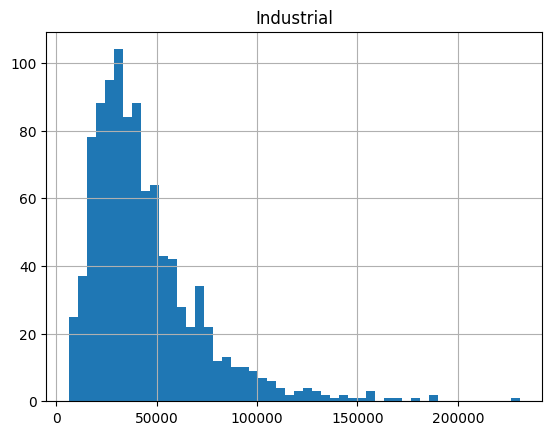

In [59]:
import matplotlib.pyplot as plt

df[df['usage_type']=='industrial']['energy_kwh'].hist(bins=50)
plt.title('Industrial')
plt.show()

criando o energy _source_distribution.csv

In [60]:
df_aneel = pd.read_csv('/content/carbon-footprint-analysis/data/raw/aneel_generation.csv',
                       encoding='latin-1',
                       sep=';',
                       decimal=',')

In [61]:
df_aneel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   DatGeracaoConjuntoDados  495 non-null    object 
 1   SigTipoGeracao           495 non-null    object 
 2   QtdUsinasPeriodo         495 non-null    int64  
 3   MdaPotenciaInstaladaKW   495 non-null    float64
 4   MesReferencia            495 non-null    int64  
 5   AnoReferencia            495 non-null    int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 23.3+ KB


In [62]:
df_aneel.head()

,DatGeracaoConjuntoDados,SigTipoGeracao,QtdUsinasPeriodo,MdaPotenciaInstaladaKW,MesReferencia,AnoReferencia
0,2026-03-01,CGH,0,0.0,12,2001
1,2026-03-01,EOL,7,21000.0,12,2001
2,2026-03-01,PCH,303,855000.0,12,2001
3,2026-03-01,UFV,0,0.0,12,2001
4,2026-03-01,UHE,133,61554000.0,12,2001


In [63]:
df_aneel['AnoReferencia'].unique()

array([2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024, 2025])

In [64]:
df_aneel = df_aneel[df_aneel['AnoReferencia']==2025]

In [65]:
df_aneel['SigTipoGeracao'].unique()

array(['EOL', 'CGH', 'UFV', 'PCH', 'UHE', 'UTE', 'UTN'], dtype=object)

In [66]:
df_grouped = df_aneel.groupby('SigTipoGeracao')['MdaPotenciaInstaladaKW'].sum()

In [67]:
df_grouped.head()

,MdaPotenciaInstaladaKW
SigTipoGeracao,
CGH,3.577829e+06
EOL,1.360294e+08
PCH,2.382840e+07
UFV,7.451254e+07
UHE,4.128522e+08


converter para probabilidade

In [68]:
df_dist = df_grouped / df_grouped.sum()

transformar e dataframe

In [69]:
df_dist.info()

<class 'pandas.core.series.Series'>
Index: 7 entries, CGH to UTN
Series name: MdaPotenciaInstaladaKW
Non-Null Count  Dtype  
--------------  -----  
7 non-null      float64
dtypes: float64(1)
memory usage: 112.0+ bytes


In [70]:
df_grouped = df_aneel.groupby('SigTipoGeracao')['MdaPotenciaInstaladaKW'].sum().reset_index()

df_grouped.columns = ['energy_source', 'total_generation']

In [71]:
df_grouped['probability'] = df_grouped['total_generation'] / df_grouped['total_generation'].sum()

df_dist = df_grouped[['energy_source', 'probability']]
df_dist = df_dist.copy()

In [72]:
df_dist.head()

,energy_source,probability
0,CGH,0.004194
1,EOL,0.159455
2,PCH,0.027932
3,UFV,0.087344
4,UHE,0.483948


In [73]:
df_dist['probability'].sum()

np.float64(1.0)

In [74]:
map_sources = {
    'UHE': 'hydro',      # Hidrelétrica grande
    'PCH': 'hydro',      # Pequena central hidrelétrica
    'CGH': 'hydro',      # Central geradora hidráulica

    'EOL': 'wind',       # Eólica

    'UFV': 'solar',      # Solar fotovoltaica

    # se aparecer depois:
    'UTE': 'thermal',    # termoelétrica (genérico)
    'UTN': 'nuclear',    # nuclear
}
df_dist['energy_source'] = df_dist['energy_source'].map(map_sources)

In [75]:
df_dist = df_dist.groupby('energy_source')['probability'].sum().reset_index()

In [76]:
df_dist['probability'] = df_dist['probability'] / df_dist['probability'].sum()

In [77]:
df_dist = df_dist.sort_values('probability', ascending=False)

In [78]:
df_dist

,energy_source,probability
0,hydro,0.516074
3,thermal,0.227796
4,wind,0.159455
2,solar,0.087344
1,nuclear,0.009331


In [79]:
df_dist.to_csv('energy _source_distribution.csv')

Inserir a emissão co2

In [80]:
emission_factors = pd.read_csv('/content/carbon-footprint-analysis/data/external/v2_energy_source_emission_factors.csv')

In [81]:
def calculate_emission(energy_kwh, energy_source, emission_df):

    row = emission_df.loc[
        emission_df['energy_source'] == energy_source
    ]

    if row.empty:
        raise ValueError(f"Fonte não encontrada: {energy_source}")

    factor = row['emission_factor'].values[0]

    return energy_kwh * factor

In [82]:
def sample_energy_source(dist_df):
    return dist_df.sample(1, weights=dist_df['probability']).iloc[0]['energy_source']

In [83]:
def generate_event(profiles, energy_dist, emission_df):

    weights = profiles['usage_type'].map(usage_probs)
    row = profiles.sample(1, weights=weights).iloc[0]

    consumption = generate_consumption(row)

    energy_source = sample_energy_source(energy_dist)

    co2 = calculate_emission(consumption, energy_source, emission_df)

    return {
        'usage_type': row['usage_type'],
        'fuel_type': row['fuel_type'],
        'energy_kwh': consumption,
        'energy_source': energy_source,
        'co2_emission': co2
    }

In [84]:
import pandas as pd
profiles = pd.read_csv('/content/carbon-footprint-analysis/data/external/v2_consumption_profiles.csv')

energy_dist = pd.read_csv('/content/carbon-footprint-analysis/data/external/v2_energy _source_distribution.csv')

emission_df = pd.read_csv('/content/carbon-footprint-analysis/data/external/v2_energy_source_emission_factors.csv')

In [85]:
event = generate_event(profiles, energy_dist, emission_df)
event

{'usage_type': 'industrial',
 'fuel_type': 'electric',
 'energy_kwh': 63395.064765388546,
 'energy_source': 'solar',
 'co2_emission': np.float64(1267.9012953077709)}

In [86]:
def generate_dataset(n, profiles, energy_dist, emission_df):
    data = []

    for _ in range(n):
        event = generate_event(profiles, energy_dist, emission_df)
        data.append(event)

    return pd.DataFrame(data)

In [87]:
df = generate_dataset(10000, profiles, energy_dist, emission_df)
df.describe()

,energy_kwh,co2_emission
count,10000.000000,10000.000000
mean,4952.190941,762.232120
std,15239.939877,4641.326370
min,55.356925,0.760515
25%,168.520219,3.390049
50%,237.388113,12.683788
75%,1395.133161,105.981559
max,243293.858867,129013.971097


In [88]:
df.head()

,usage_type,fuel_type,energy_kwh,energy_source,co2_emission
0,residential,electric,146.884496,solar,2.937690
1,other,electric,4491.269366,hydro,89.825387
2,agriculture,electric,743.159717,hydro,14.863194
3,commercial,electric,909.681344,hydro,18.193627
4,residential,electric,110.552149,hydro,2.211043


Adicionando ID e datas

In [89]:
company_id = f"C{np.random.randint(1000,9999)}"

In [90]:
date = pd.Timestamp('2025-01-01') + pd.to_timedelta(np.random.randint(0, 365), unit='D')

In [91]:
states = [
'SP','MG','RJ','BA','PR','RS','SC','GO','PE','CE',
'PA','MT','ES','DF','MS','MA','RN','PB','AL','PI',
'RO','SE','TO','AC','AP','RR','AM'
]

state_weights = [
0.22,0.10,0.09,0.07,0.06,0.06,0.04,0.04,0.04,0.04,
0.03,0.03,0.02,0.02,0.02,0.02,0.015,0.015,0.01,0.01,
0.008,0.008,0.006,0.005,0.005,0.003,0.02
]


In [92]:
len(states), len(state_weights)

(27, 27)

In [93]:
state_weights = np.array(state_weights)
state_weights = state_weights / state_weights.sum()
state_weights

array([0.21890547, 0.09950249, 0.08955224, 0.06965174, 0.05970149,
       0.05970149, 0.039801  , 0.039801  , 0.039801  , 0.039801  ,
       0.02985075, 0.02985075, 0.0199005 , 0.0199005 , 0.0199005 ,
       0.0199005 , 0.01492537, 0.01492537, 0.00995025, 0.00995025,
       0.0079602 , 0.0079602 , 0.00597015, 0.00497512, 0.00497512,
       0.00298507, 0.0199005 ])

In [94]:
def generate_event(profiles, energy_dist, emission_df):

    weights = profiles['usage_type'].map(usage_probs)
    row = profiles.sample(1, weights=weights).iloc[0]

    consumption = generate_consumption(row)

    energy_source = sample_energy_source(energy_dist)

    co2 = calculate_emission(consumption, energy_source, emission_df)

    return {
        'company_id': f"C{np.random.randint(100000,999999)}",
        'date': pd.Timestamp('2025-01-01') + pd.to_timedelta(np.random.randint(0,365), unit='D'),
        'state': np.random.choice(states, p=state_weights),
        'usage_type': row['usage_type'],
        'fuel_type': row['fuel_type'],
        'energy_kwh': consumption,
        'energy_source': energy_source,
        'co2_emission': co2
    }

In [95]:
def generate_dataset(n, profiles, energy_dist, emission_df):
    data = []

    for _ in range(n):
        event = generate_event(profiles, energy_dist, emission_df)
        data.append(event)

    return pd.DataFrame(data)

In [96]:
df = generate_dataset(10000, profiles, energy_dist, emission_df)
df.describe()

,date,energy_kwh,co2_emission
count,10000,10000.000000,10000.000000
mean,2025-07-01 19:46:16.320000,5206.067591,819.154721
min,2025-01-01 00:00:00,61.917613,0.773908
25%,2025-04-01 00:00:00,166.138491,3.322512
50%,2025-07-02 00:00:00,235.361017,12.788275
75%,2025-10-03 00:00:00,1421.854210,104.942316
max,2025-12-31 00:00:00,167376.929964,94029.901205
std,NaN,15691.530994,4802.208616


In [97]:
df

,company_id,date,state,usage_type,fuel_type,energy_kwh,energy_source,co2_emission
0,C116364,2025-01-19,GO,agriculture,electric,463.553123,solar,9.271062
1,C299270,2025-03-13,PE,industrial,electric,51062.597339,hydro,1021.251947
2,C440844,2025-05-16,RJ,residential,electric,120.510352,solar,2.410207
3,C677124,2025-10-30,MG,residential,electric,214.932427,solar,4.298649
4,C871751,2025-11-25,PR,residential,electric,148.880736,solar,2.977615
...,...,...,...,...,...,...,...,...
9995,C301175,2025-12-19,RS,residential,electric,161.637257,hydro,3.232745
9996,C334889,2025-06-07,SP,industrial,electric,94549.669691,hydro,1890.993394
9997,C894389,2025-03-06,RS,residential,electric,162.958268,thermal,97.774961
9998,C344851,2025-01-01,CE,residential,electric,120.416775,thermal,72.250065


Adicionando regras mais realistas, do jeito que esta esta pode criar industria pesadas na msm probabilidade entre ACRE e São Paulo

In [98]:
df_epe = pd.read_csv('/content/carbon-footprint-analysis/data/raw/EPE - Dados_abertos_Consumo_Mensal.CSV',
                    encoding='latin-1',
                    sep=';',
                    decimal=',')

In [99]:
df_epe.columns

Index(['Data', 'DataExcel', 'UF', 'Regiao', 'Sistema', 'Classe',
       'TipoConsumidor', 'Consumo', 'Consumidores', 'DataVersao'],
      dtype='object')

In [100]:
df_epe.head(5)

,Data,DataExcel,UF,Regiao,Sistema,Classe,TipoConsumidor,Consumo,Consumidores,DataVersao
0,20251201,01/12/2025,AC,Norte,SISTEMAS ISOLADOS,Comercial,Cativo,"175,7",478,23/02/2026
1,20251201,01/12/2025,AC,Norte,SISTEMAS ISOLADOS,Industrial,Cativo,"7,0",4,23/02/2026
2,20251201,01/12/2025,AC,Norte,SISTEMAS ISOLADOS,Outros,Cativo,"495,1",382,23/02/2026
3,20251201,01/12/2025,AC,Norte,SISTEMAS ISOLADOS,Residencial,Cativo,"1.266,8",8.862,23/02/2026
4,20251201,01/12/2025,AC,Norte,SISTEMAS ISOLADOS,Rural,Cativo,"1.181,1",125,23/02/2026


In [101]:
df_epe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59243 entries, 0 to 59242
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Data            59243 non-null  int64 
 1   DataExcel       59243 non-null  object
 2   UF              59243 non-null  object
 3   Regiao          59243 non-null  object
 4   Sistema         59243 non-null  object
 5   Classe          59243 non-null  object
 6   TipoConsumidor  59243 non-null  object
 7   Consumo         59243 non-null  object
 8   Consumidores    59243 non-null  object
 9   DataVersao      59243 non-null  object
dtypes: int64(1), object(9)
memory usage: 4.5+ MB


In [102]:
df_epe['Consumo'] = (
    df_epe['Consumo']
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [103]:
df_sector_state = (
    df_epe
    .groupby(['UF','Classe'])['Consumo']
    .sum()
    .reset_index()
)

In [104]:
df_sector_state.head(20)

,UF,Classe,Consumo
0,AC,Comercial,4437987.7
1,AC,Industrial,841467.5
2,AC,Outros,4101501.8
3,AC,Residencial,9096890.3
4,AC,Rural,964581.4
5,AL,Comercial,14975797.6
6,AL,Industrial,37928026.3
7,AL,Outros,13214271.0
8,AL,Residencial,27863262.6
9,AL,Rural,3855553.4


In [105]:
df_sector_state['probability'] = (
    df_sector_state
    .groupby('UF')['Consumo']
    .transform(lambda x: x / x.sum())
)

In [106]:
usage_distribution_by_state = df_sector_state.pivot(
    index='UF',
    columns='Classe',
    values='probability'
)

In [107]:
usage_distribution_by_state.to_csv('usage_distribution_by_state.csv')

In [108]:
states = [
'SP','MG','RJ','BA','PR','RS','SC','GO','PE','CE',
'PA','MT','ES','DF','MS','MA','RN','PB','AL','PI',
'RO','SE','TO','AC','AP','RR','AM'
]

state_weights = [
0.22,0.10,0.09,0.07,0.06,0.06,0.04,0.04,0.04,0.04,
0.03,0.03,0.02,0.02,0.02,0.02,0.015,0.015,0.01,0.01,
0.008,0.008,0.006,0.005,0.005,0.003,0.02
]

state_weights = np.array(state_weights)
state_weights = state_weights / state_weights.sum()

In [109]:
def generate_event(profiles, energy_dist, emission_df):

    # sorteia estado
    state = np.random.choice(states, p=state_weights)

    # pega probabilidades de setor para esse estado
    usage_probs_state = usage_distribution_by_state.loc[state].values
    usage_probs_state = usage_probs_state / usage_probs_state.sum()

    # sorteia setor
    usage_types = profiles['usage_type'].unique()

    usage_type = np.random.choice(
        usage_types,
        p=usage_probs_state
    )

    # filtra profiles para esse setor
    profiles_subset = profiles[profiles['usage_type'] == usage_type]

    # escolhe linha de profile
    row = profiles_subset.sample(1).iloc[0]

    # gera consumo
    consumption = generate_consumption(row)

    # sorteia fonte de energia
    energy_source = sample_energy_source(energy_dist)

    # calcula CO2
    co2 = calculate_emission(consumption, energy_source, emission_df)

    return {
        'company_id': f"C{np.random.randint(100000,999999)}",
        'date': pd.Timestamp('2025-01-01') + pd.to_timedelta(np.random.randint(0,365), unit='D'),
        'state': np.random.choice(states, p=state_weights),
        'usage_type': usage_type,
        'fuel_type': row['fuel_type'],
        'energy_kwh': consumption,
        'energy_source': energy_source,
        'co2_emission': co2
    }

In [110]:
def generate_dataset(n, profiles, energy_dist, emission_df):
    data = []

    for _ in range(n):
        event = generate_event(profiles, energy_dist, emission_df)
        data.append(event)

    return pd.DataFrame(data)

In [111]:
df = generate_dataset(10000, profiles, energy_dist, emission_df)
df.describe()

,date,energy_kwh,co2_emission
count,10000,10000.000000,10000.000000
mean,2025-06-28 15:22:53.760000,9832.208893,1538.407456
min,2025-01-01 00:00:00,53.964040,0.724653
25%,2025-03-31 00:00:00,206.485510,4.929647
50%,2025-06-26 00:00:00,1822.086249,75.300054
75%,2025-09-26 00:00:00,6338.751288,407.480357
max,2025-12-31 00:00:00,367659.792448,209866.115108
std,NaN,20944.032076,6774.302342


In [112]:
df

,company_id,date,state,usage_type,fuel_type,energy_kwh,energy_source,co2_emission
0,C444796,2025-06-09,SP,residential,electric,203.437249,hydro,4.068745
1,C116932,2025-12-31,RS,residential,electric,226.566643,hydro,4.531333
2,C498191,2025-03-20,RS,residential,electric,164.840850,thermal,98.904510
3,C546719,2025-04-07,MG,industrial,electric,27007.095088,thermal,16204.257053
4,C644760,2025-11-11,GO,residential,electric,186.093416,hydro,3.721868
...,...,...,...,...,...,...,...,...
9995,C368029,2025-11-05,MG,industrial,electric,46910.162841,thermal,28146.097704
9996,C281263,2025-01-22,MG,other,electric,6244.708998,wind,62.447090
9997,C701372,2025-01-08,BA,other,electric,13981.491099,hydro,279.629822
9998,C776527,2025-12-17,AL,commercial,electric,1773.896463,hydro,35.477929


In [113]:
df = generate_dataset(10000, profiles, energy_dist, emission_df)

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   company_id     10000 non-null  object        
 1   date           10000 non-null  datetime64[ns]
 2   state          10000 non-null  object        
 3   usage_type     10000 non-null  object        
 4   fuel_type      10000 non-null  object        
 5   energy_kwh     10000 non-null  float64       
 6   energy_source  10000 non-null  object        
 7   co2_emission   10000 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 625.1+ KB


Extraindo a probabilidade do tramanho do negocio small, medium e large. Para criar dataset mais realista !

In [128]:
df_epe = pd.read_csv('/content/carbon-footprint-analysis/data/raw/EPE - Dados_abertos_Consumo_Mensal.CSV',
                    encoding='latin-1',
                    sep=';',
                    decimal=',')

In [129]:
df_epe['Consumo'] = (
    df_epe['Consumo']
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [130]:
df_epe['DataExcel'] = pd.to_datetime(df_epe['DataExcel'], dayfirst=True)

In [131]:
df_epe['year'] = df_epe['DataExcel'].dt.year
df_epe['month'] = df_epe['DataExcel'].dt.month

In [132]:
df_2025 = df_epe[df_epe['year'] == 2025].copy()

In [133]:
df_2025

,Data,DataExcel,UF,Regiao,Sistema,Classe,TipoConsumidor,Consumo,Consumidores,DataVersao,year,month
0,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Comercial,Cativo,175.7,478,23/02/2026,2025,12
1,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Industrial,Cativo,7.0,4,23/02/2026,2025,12
2,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Outros,Cativo,495.1,382,23/02/2026,2025,12
3,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Residencial,Cativo,1266.8,8.862,23/02/2026,2025,12
4,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Rural,Cativo,1181.1,125,23/02/2026,2025,12
...,...,...,...,...,...,...,...,...,...,...,...,...
3323,20250101,2025-01-01,TO,Norte,NORTE INTERLIGADO,Outros,Cativo,23253.4,10.272,23/02/2026,2025,1
3324,20250101,2025-01-01,TO,Norte,NORTE INTERLIGADO,Outros,Livre,4551.3,92,23/02/2026,2025,1
3325,20250101,2025-01-01,TO,Norte,NORTE INTERLIGADO,Residencial,Cativo,112036.0,596.482,23/02/2026,2025,1
3326,20250101,2025-01-01,TO,Norte,NORTE INTERLIGADO,Rural,Cativo,15481.4,41.242,23/02/2026,2025,1


In [141]:
df_2025['DataExcel'].unique()

<DatetimeArray>
['2025-12-01 00:00:00', '2025-11-01 00:00:00', '2025-10-01 00:00:00',
 '2025-09-01 00:00:00', '2025-08-01 00:00:00', '2025-07-01 00:00:00',
 '2025-06-01 00:00:00', '2025-05-01 00:00:00', '2025-04-01 00:00:00',
 '2025-03-01 00:00:00', '2025-02-01 00:00:00', '2025-01-01 00:00:00']
Length: 12, dtype: datetime64[ns]

In [134]:
df_2025['year'].unique()

array([2025], dtype=int32)

In [135]:
df_epe = df_2025.copy()

In [136]:
def classify_company_size(row):

    usage = row['Classe']
    energy = row['Consumo']

    if usage == 'Industrial':
        if energy < 20000:
            return 'small'
        elif energy < 100000:
            return 'medium'
        else:
            return 'large'

    if usage == 'Comercial':
        if energy < 5000:
            return 'small'
        elif energy < 30000:
            return 'medium'
        else:
            return 'large'

    if usage == 'Residencial':
        return 'small'

    if usage == 'Rural':
        if energy < 10000:
            return 'small'
        elif energy < 50000:
            return 'medium'
        else:
            return 'large'

    if usage == 'Outros':
        if energy < 10000:
            return 'small'
        elif energy < 50000:
            return 'medium'
        else:
            return 'large'

In [137]:
df_epe['company_size'] = df_epe.apply(classify_company_size, axis=1)

In [138]:
df_epe['company_size'].value_counts()

,count
company_size,
small,1408
large,1255
medium,665


In [139]:
size_dist = (
    df_epe
    .groupby('Classe')['company_size']
    .value_counts(normalize=True)
    .reset_index(name='probability')
)

In [140]:
size_dist

,Classe,company_size,probability
0,Comercial,large,0.736990
1,Comercial,medium,0.174402
2,Comercial,small,0.088608
3,Industrial,small,0.459198
4,Industrial,large,0.343015
5,Industrial,medium,0.197787
6,Outros,large,0.438028
7,Outros,medium,0.339437
8,Outros,small,0.222535
9,Residencial,small,1.000000


In [143]:
size_dist.to_csv(
    'v2_company_size_distribution_by_usage.csv',
    index=False
)

calculando a variancia por mes, meses podem impactar no consumo de energia !

In [144]:
df_epe = pd.read_csv('/content/carbon-footprint-analysis/data/raw/EPE - Dados_abertos_Consumo_Mensal.CSV',
                    encoding='latin-1',
                    sep=';',
                    decimal=',')

In [145]:
df_epe['Consumo'] = (
    df_epe['Consumo']
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [146]:
df_epe['DataExcel'] = pd.to_datetime(df_epe['DataExcel'], dayfirst=True)

In [147]:
df_epe['year'] = df_epe['DataExcel'].dt.year
df_epe['month'] = df_epe['DataExcel'].dt.month

In [148]:
df_2025 = df_epe[df_epe['year'] == 2025].copy()

In [149]:
df_2025

,Data,DataExcel,UF,Regiao,Sistema,Classe,TipoConsumidor,Consumo,Consumidores,DataVersao,year,month
0,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Comercial,Cativo,175.7,478,23/02/2026,2025,12
1,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Industrial,Cativo,7.0,4,23/02/2026,2025,12
2,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Outros,Cativo,495.1,382,23/02/2026,2025,12
3,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Residencial,Cativo,1266.8,8.862,23/02/2026,2025,12
4,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Rural,Cativo,1181.1,125,23/02/2026,2025,12
...,...,...,...,...,...,...,...,...,...,...,...,...
3323,20250101,2025-01-01,TO,Norte,NORTE INTERLIGADO,Outros,Cativo,23253.4,10.272,23/02/2026,2025,1
3324,20250101,2025-01-01,TO,Norte,NORTE INTERLIGADO,Outros,Livre,4551.3,92,23/02/2026,2025,1
3325,20250101,2025-01-01,TO,Norte,NORTE INTERLIGADO,Residencial,Cativo,112036.0,596.482,23/02/2026,2025,1
3326,20250101,2025-01-01,TO,Norte,NORTE INTERLIGADO,Rural,Cativo,15481.4,41.242,23/02/2026,2025,1


In [150]:
df_epe = df_2025.copy()

In [153]:
df_epe['month'] = df_epe['DataExcel'].dt.month

In [154]:
monthly_stats = (
    df_epe
    .groupby(['UF','Classe','month'])['Consumo']
    .agg(['mean','var'])
    .reset_index()
)

In [155]:
annual_mean = (
    df_epe
    .groupby(['UF','Classe'])['Consumo']
    .mean()
    .reset_index()
    .rename(columns={'Consumo':'annual_mean'})
)

In [156]:
monthly_stats = monthly_stats.merge(
    annual_mean,
    on=['UF','Classe']
)

In [157]:
monthly_stats['seasonal_factor'] = (
    monthly_stats['mean'] /
    monthly_stats['annual_mean']
)

In [158]:
monthly_stats

,UF,Classe,month,mean,var,annual_mean,seasonal_factor
0,AC,Comercial,1,7714.300000,6.714684e+07,7870.066667,0.980208
1,AC,Comercial,2,7516.866667,6.767137e+07,7870.066667,0.955121
2,AC,Comercial,3,7665.733333,6.396008e+07,7870.066667,0.974037
3,AC,Comercial,4,7678.133333,6.649973e+07,7870.066667,0.975612
4,AC,Comercial,5,8107.200000,7.436601e+07,7870.066667,1.030131
...,...,...,...,...,...,...,...
1615,TO,Rural,8,13812.350000,2.121120e+08,10657.095833,1.296071
1616,TO,Rural,9,12308.500000,1.619640e+08,10657.095833,1.154958
1617,TO,Rural,10,10554.700000,1.126921e+08,10657.095833,0.990392
1618,TO,Rural,11,10315.150000,1.275795e+08,10657.095833,0.967914


In [159]:
monthly_stats = monthly_stats[[
    'UF',
    'Classe',
    'month',
    'seasonal_factor',
    'var'
]]

monthly_stats.to_csv(
    'v2_seasonality_state_class_month.csv',
    index=False
)